# Paper Summary: Supervision Exists Everywhere: A Data Efficient Contrastive Language-Image Pre-Training Paradigm (DeCLIP)

# https://arxiv.org/pdf/2110.05208



## Abstract

The paper introduces **DeCLIP (Data-efficient Contrastive Language-Image Pre-training)**, a framework designed to improve the data efficiency of CLIP-style vision-language pretraining. Traditional CLIP models require hundreds of millions of image-text pairs to achieve strong zero-shot performance. The authors argue that existing approaches underutilize the supervision already present within multimodal data.

DeCLIP enhances contrastive learning by incorporating:

1. Self-supervision within image and text modalities.
2. Cross-modal multi-view supervision.
3. Nearest-neighbor supervision from semantically similar image-text pairs.

These additional supervisory signals enable DeCLIP to achieve superior performance while using substantially less training data.

---

## Problems

### 1. Extreme Data Requirements

CLIP requires approximately 400 million image-text pairs, making training expensive and inaccessible for many researchers and organizations.

### 2. Underutilized Supervision

Existing contrastive language-image models rely primarily on a single supervision signal:

$$
(\text{Image}, \text{Text})
$$

and ignore valuable information available:

- Within images themselves.
- Within text descriptions.
- Across augmented views.
- Across semantically related samples.

### 3. Inefficient Learning

Many semantically similar image-text pairs exist in large datasets but are treated as unrelated negatives, causing potentially useful information to be discarded.

---

## Proposed Solutions

The authors propose **DeCLIP**, which augments CLIP with three complementary supervision mechanisms.

### 1. Self-Supervision (SS)

Apply self-supervised learning independently within each modality.

#### Image Self-Supervision

Uses SimSiam to maximize similarity between two augmented image views.

#### Text Self-Supervision

Uses Masked Language Modeling (MLM) similar to BERT.

---

### 2. Multi-View Supervision (MVS)

Generate multiple augmented views for both images and text.

Instead of learning only:

$$
(z^I, z^T)
$$

DeCLIP also learns from:

$$
(z^I,\tilde z^T)
$$

$$
(\tilde z^I,z^T)
$$

$$
(\tilde z^I,\tilde z^T)
$$

This creates additional cross-modal supervision and improves robustness.

---

### 3. Nearest-Neighbor Supervision (NNS)

Retrieve semantically similar text descriptions in embedding space using a feature queue.

If

$$
z^T
$$

is a text embedding, DeCLIP finds:

$$
z^{T'}
= NN(z^T)
$$

and treats it as an additional positive supervisory signal for the paired image.

This allows the model to exploit latent semantic relationships among different samples.

---

## Purpose

The primary goal is to improve the efficiency of vision-language pretraining by exploiting all available supervision within multimodal data rather than scaling training datasets indefinitely.

Specifically, the authors aim to:

- Reduce dependence on massive datasets.
- Improve zero-shot recognition.
- Improve transferability to downstream tasks.
- Create a scalable framework compatible with different architectures.

---

## Methodology

### Baseline: CLIP

CLIP minimizes a contrastive InfoNCE loss:

$$
L_I
=
-\frac{1}{N}
\sum_{i=1}^{N}
\log
\frac{
\exp(\text{sim}(z_i^I,z_i^T)/\tau)
}{
\sum_{j=1}^{N}
\exp(\text{sim}(z_i^I,z_j^T)/\tau)
}
$$

where:

- $z^I$ = image embedding
- $z^T$ = text embedding
- $\tau$ = learnable temperature

---

### DeCLIP Objective

The final loss combines all supervision sources:

$$
L_{DeCLIP}
=
(1-\alpha-\beta-\gamma)L_{CLIP}
+
\alpha(L_{ISS}+L_{TSS})
+
\beta L_{MVS}
+
\gamma L_{NNS}
$$

where:

- $L_{CLIP}$ = original image-text contrastive loss
- $L_{ISS}$ = image self-supervision
- $L_{TSS}$ = text self-supervision
- $L_{MVS}$ = multi-view supervision
- $L_{NNS}$ = nearest-neighbor supervision

---

### Data

DeCLIP is trained using:

| Dataset | Size |
|----------|--------|
| CC3M | 3M |
| CC12M | 11M |
| YFCC | 15M |
| Open-source total | 29M |
| Web-crawled data | 59M |
| Full DeCLIP dataset | 88M |

This is substantially smaller than:

| Model | Training Data |
|---------|-------------|
| CLIP | 400M |
| ALIGN | 1.8B |

---

## Results

### Zero-Shot ImageNet Performance

| Model | Data | Top-1 Accuracy |
|---------|---------|---------|
| CLIP ResNet50 | 400M | 59.6% |
| DeCLIP ResNet50 | 88M | 62.5% |
| CLIP ViT-B/32 | 400M | 63.2% |
| DeCLIP ViT-B/32 | 88M | 66.2% |
| CLIP R50×64 | 400M | 73.6% |
| DeCLIP RegNetY-64GF | 88M | 73.7% |

Key observation:

- DeCLIP achieves higher accuracy while using approximately:

$$
4.5\times
$$

less data.

In one experiment, DeCLIP reached:

$$
60.4\%
$$

ImageNet accuracy using only

$$
56M
$$

samples, outperforming CLIP trained with

$$
400M
$$

samples.

---

### Downstream Transfer Learning

Linear evaluation was performed on 11 datasets including:

- CIFAR-10
- CIFAR-100
- Flowers
- Cars
- Food101
- Caltech
- Aircraft
- DTD
- ImageNet

Results:

- DeCLIP-ResNet50 outperformed CLIP on 8 of 11 datasets.
- Average improvement:

$$
+0.8\%
$$

- DeCLIP-ViT-B/32 improved average performance by:

$$
+0.5\%
$$

---

### Ablation Study

Starting from baseline CLIP:

| Configuration | Zero-Shot Accuracy |
|---------------|-------------------|
| CLIP | 20.6% |
| + MVS | 24.8% |
| + MVS + SS | 25.4% |
| + MVS + SS + NNS | 27.2% |

Contribution of each component:

- Multi-View Supervision: +4.2%
- Self-Supervision: +0.6%
- Nearest-Neighbor Supervision: +1.8%

The largest gain comes from Multi-View Supervision.

---

## Conclusions

DeCLIP demonstrates that substantial supervision already exists within multimodal datasets and can be exploited to dramatically improve training efficiency.

The key insights are:

1. Contrastive image-text learning should not rely solely on paired supervision.
2. Self-supervision within each modality provides useful complementary signals.
3. Multi-view supervision significantly strengthens cross-modal alignment.
4. Nearest-neighbor supervision captures semantic relationships across samples.
5. Better supervision is often more effective than simply increasing dataset size.

Overall, DeCLIP achieves state-of-the-art data efficiency, outperforming CLIP while using approximately 4.5×–7.1× less training data, and establishes a new direction for scalable multimodal representation learning.

# Mathematical and Statistical Content Summary


Although DeCLIP is primarily a representation learning paper, several important mathematical concepts underpin the method. The paper introduces new loss functions, similarity measures, nearest-neighbor retrieval, and experimental evaluation metrics.

---

# 1. Contrastive Learning

## Concept

The foundation of DeCLIP is **contrastive learning**.

The goal is:

- Pull matching image-text pairs closer together.
- Push mismatched image-text pairs farther apart.

For example:

- Image: Cat
- Text: "A cute white cat"

Their embeddings should be similar.

Meanwhile:

- Image: Cat
- Text: "A red sports car"

Should be dissimilar.

---

# 2. Embedding Space

## Concept

Images and texts are converted into vectors called embeddings.

Let

$$
z_i^I
$$

represent the embedding of image \(i\),

and

$$
z_i^T
$$

represent the embedding of text \(i\).

Both are projected into the same feature space.

This allows image and text similarities to be computed directly.

---

# 3. Cosine Similarity / Dot Product Similarity

## Equation

The paper measures similarity using a dot product between normalized embeddings:

$$
\text{sim}(z_i^I,z_j^T)
$$

Because embeddings are L2-normalized, dot product becomes cosine similarity.

---

## Meaning

Values near:

$$
1
$$

indicate highly similar semantics.

Values near:

$$
-1
$$

indicate dissimilar semantics.

---

## Role in DeCLIP

Used everywhere:

- Contrastive loss
- Multi-view supervision
- Nearest-neighbor retrieval

---

# 4. InfoNCE Loss

## Equation

The core CLIP objective is:

$$
L_I
=
-\frac{1}{N}
\sum_{i=1}^{N}
\log
\frac{
\exp(\text{sim}(z_i^I,z_i^T)/\tau)
}{
\sum_{j=1}^{N}
\exp(\text{sim}(z_i^I,z_j^T)/\tau)
}
$$

---

## Interpretation

The numerator:

$$
\exp(\text{sim}(z_i^I,z_i^T)/\tau)
$$

represents the correct image-text pair.

The denominator:

$$
\sum_{j=1}^{N}
\exp(\text{sim}(z_i^I,z_j^T)/\tau)
$$

contains all possible text candidates.

The model learns to assign the highest similarity to the correct pair.

---

## Role in the Paper

This is the baseline CLIP objective.

DeCLIP extends it with additional supervision rather than replacing it.

---

# 5. Temperature Scaling

## Parameter

$$
\tau
$$

appears inside InfoNCE.

---

## Purpose

Controls the sharpness of similarity scores.

Small values:

$$
\tau \rightarrow 0
$$

make the model focus strongly on the best match.

Larger values produce softer probability distributions.

---

## Role in DeCLIP

Used exactly as in CLIP.

The paper initializes:

$$
\tau = 0.07
$$

during training.

---

# 6. Self-Supervised Learning (SimSiam)

## Concept

For image self-supervision, DeCLIP uses SimSiam.

Two augmented versions of the same image are created:

$$
x^I
$$

and

$$
\tilde{x}^I
$$

---

## Objective

Learn representations that remain similar despite augmentations.

The optimization maximizes similarity between:

$$
p^I
$$

and

$$
\tilde{z}^I
$$

using negative cosine similarity.

---

## Role

Improves image representations without requiring extra labels.

---

# 7. Masked Language Modeling (MLM)

## Concept

Used as text self-supervision.

Random tokens are masked:

```
A cute [MASK] cat
```

The model predicts:

```
white
```

---

## Statistical Objective

A classification problem trained with cross-entropy loss.

---

## Role

Improves text understanding independently of image-text matching.

---

# 8. Multi-View Supervision (MVS)

## Concept

Each sample generates multiple views.

Images:

$$
z^I,\ \tilde z^I
$$

Texts:

$$
z^T,\ \tilde z^T
$$

---

## Additional Contrastive Pairs

Instead of learning only:

$$
(z^I,z^T)
$$

DeCLIP also learns:

$$
(z^I,\tilde z^T)
$$

$$
(\tilde z^I,z^T)
$$

$$
(\tilde z^I,\tilde z^T)
$$

---

## Statistical Effect

Creates:

$$
2 \times 2 = 4
$$

possible pairings.

This provides three additional supervision signals.

---

## Role

Improves robustness and data efficiency.

The ablation study shows it contributes the largest performance gain.

---

# 9. Nearest Neighbor Search

## Concept

For each text embedding:

$$
z^T
$$

the model finds:

$$
z^{T'}
=
NN(z^T)
$$

where \(NN\) denotes the nearest neighbor in embedding space.

---

## Distance Metric

Nearest neighbors are selected using cosine similarity.

---

## Role

Adds semantically similar descriptions as additional positive examples.

Example:

Text A:

```
A man playing with his dog.
```

Nearest Neighbor:

```
Portrait of a man playing with his dog.
```

Both provide similar supervision.

---

# 10. Feature Queue

## Concept

Searching the entire dataset is computationally expensive.

The paper maintains a FIFO queue:

$$
Q
$$

of previously observed embeddings.

Queue size:

$$
64K
$$

embeddings.

---

## Role

Provides an efficient approximation to global nearest-neighbor search.

---

# 11. Overall DeCLIP Objective Function

## Equation

The complete optimization target is:

$$
L_{DeCLIP}
=
(1-\alpha-\beta-\gamma)L_{CLIP}
+
\alpha(L_{ISS}+L_{TSS})
+
\beta L_{MVS}
+
\gamma L_{NNS}
$$

---

## Components

### CLIP Loss

$$
L_{CLIP}
$$

Original image-text contrastive loss.

---

### Image Self-Supervision

$$
L_{ISS}
$$

SimSiam loss.

---

### Text Self-Supervision

$$
L_{TSS}
$$

Masked language modeling loss.

---

### Multi-View Loss

$$
L_{MVS}
$$

Additional augmented image-text pairs.

---

### Nearest Neighbor Loss

$$
L_{NNS}
$$

Contrastive learning with nearest-neighbor text descriptions.

---

## Weighting Parameters

The paper sets:

$$
\alpha = \beta = \gamma = 0.2
$$

meaning each auxiliary supervision contributes equally.

---

# 12. Statistical Evaluation Metrics

## Top-1 Accuracy

Primary metric:

$$
\text{Accuracy}
=
\frac{\text{Correct Predictions}}
{\text{Total Samples}}
\times 100
$$

Used for:

- ImageNet zero-shot evaluation
- Downstream classification

---

## Zero-Shot Evaluation

No task-specific training labels are used.

The model predicts directly using text prompts.

Example:

```
"A photo of a cat"
"A photo of a dog"
```

The most similar text embedding determines the class.

---

## Linear Probe Evaluation

The image encoder is frozen.

A linear classifier is trained on top of extracted features.

This measures representation quality independently of end-to-end fine-tuning.

---

# 13. Ablation Analysis

The paper performs controlled experiments to measure contributions of each component.

| Method | Accuracy |
|----------|----------|
| CLIP | 20.6% |
| + MVS | 24.8% |
| + MVS + SS | 25.4% |
| + MVS + SS + NNS | 27.2% |

Performance gains:

| Component | Improvement |
|------------|------------|
| MVS | +4.2% |
| SS | +0.6% |
| NNS | +1.8% |

This is essentially a statistical attribution study showing which components contribute most to performance.

---

# Key Mathematical Takeaways

The paper revolves around five core mathematical ideas:

1. **Contrastive Learning (InfoNCE)** for aligning image and text embeddings.
2. **Cosine Similarity** as the fundamental similarity measure.
3. **Self-Supervised Learning** through SimSiam and MLM.
4. **Nearest-Neighbor Retrieval** in embedding space using similarity search.
5. **Weighted Multi-Objective Optimization** combining four loss functions into a single training objective.

Mathematically, the most important contribution is not a new network architecture but the formulation of a richer objective function that combines multiple sources of supervision into a unified contrastive learning framework.

# Research Gaps, Limitations, and Proposed Solutions


| Research Problem / Gap | Limitation in Prior Work | DeCLIP's Proposed Solution |
|------------------------|--------------------------|----------------------------|
| Excessive dependence on large-scale image-text datasets | CLIP and ALIGN require hundreds of millions to billions of image-text pairs (400M–1.8B), making training computationally expensive and inaccessible to most researchers. | Introduces a data-efficient training paradigm that extracts additional supervision from existing data, achieving competitive or superior performance with significantly fewer samples. |
| Reliance on a single image-text contrastive signal | Prior methods treat each image-text pair as the sole source of supervision, ignoring other useful learning signals available within the data. | Combines multiple complementary supervision sources: contrastive supervision, self-supervision, multi-view supervision, and nearest-neighbor supervision. |
| Underutilization of modality-specific structure | Existing CLIP-style models do not explicitly exploit rich internal structure within images or text. | Incorporates self-supervised learning for both modalities: SimSiam for images and Masked Language Modeling (MLM) for text. |
| Weak robustness to visual and linguistic variations | Original CLIP primarily uses a single image view and no text augmentation, limiting invariance to transformations and paraphrases. | Introduces Multi-View Supervision (MVS) by generating augmented image and text views and contrasting all image-text view combinations. |
| Lack of semantic information sharing across samples | Similar image-text pairs in the dataset are treated as unrelated examples, causing valuable semantic relationships to be ignored. | Introduces Nearest-Neighbor Supervision (NNS), which retrieves semantically similar text embeddings and uses them as additional positive supervision. |
| Inefficient exploitation of multimodal data | Scaling performance in prior work mainly relies on collecting more data rather than extracting more information from existing data. | Demonstrates that richer supervision can improve performance more effectively than simply increasing dataset size. |
| Limited research on self-supervision in large-scale vision-language pretraining | Previous multimodal contrastive frameworks largely focus on image-text alignment and neglect self-supervised objectives at web scale. | Systematically integrates image and text self-supervision into large-scale contrastive language-image pretraining. |
| Limited exploration of cross-modal multi-view learning | Existing methods rarely leverage multiple augmented views across both modalities simultaneously. | Proposes a unified cross-modal multi-view framework that aligns multiple image and text augmentations through contrastive learning. |
| Absence of semantic-level augmentation mechanisms | Traditional data augmentation operates mainly at pixel or token level and may not capture semantic similarity. | Uses nearest-neighbor retrieval in embedding space as a form of semantic-level augmentation. |
| Poor data efficiency of vision-language models | Performance gains in prior work often require substantially larger datasets and compute budgets. | Achieves higher zero-shot and transfer-learning performance while using approximately 4.5×–7.1× less training data than CLIP. |

## Core Insight

The central research hypothesis of DeCLIP is that **supervision already exists throughout multimodal datasets and is significantly underutilized by conventional contrastive language-image pretraining methods**. Rather than scaling data collection indefinitely, the paper proposes extracting richer supervisory signals from existing image-text pairs through self-supervision, multi-view learning, and nearest-neighbor semantic supervision.

In [1]:
# DeCLIP-Inspired FashionMNIST Lab (Single Cell)

## Important Note

# The original DeCLIP paper is a **large-scale multimodal vision-language model** trained on tens of millions of image-text pairs using:

# - CLIP contrastive learning
# - Image self-supervision (SimSiam)
# - Text self-supervision (MLM)
# - Multi-view supervision
# - Nearest-neighbor supervision

# FashionMNIST does not contain text descriptions, so this educational implementation creates:

# - Image encoder (CNN)
# - Pseudo-text encoder (class-name prompts)
# - Contrastive CLIP loss
# - SimSiam image self-supervision
# - Multi-view supervision
# - Grad-CAM visualization
# - Training curves
# - Accuracy curves
# - Confusion matrix
# - Sample predictions
# - Embedding visualization (t-SNE)

# This is **not an exact reproduction** of the paper but a teaching-oriented DeCLIP-inspired implementation demonstrating all major ideas in a compact notebook.



# ============================================================
# DeCLIP Inspired FashionMNIST Educational Lab
# Single Cell Implementation
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as T

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix
from sklearn.manifold import TSNE

from tqdm.auto import tqdm

In [2]:
# ------------------------------------------------------------
# Device
# ------------------------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ------------------------------------------------------------
# FashionMNIST Classes
# ------------------------------------------------------------

classes = [
    "T-shirt",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]

Device: cuda


In [3]:
# ------------------------------------------------------------
# Data Augmentation
# (Multi-view supervision)
# ------------------------------------------------------------

train_transform = T.Compose([
    T.RandomHorizontalFlip(),
    T.RandomRotation(10),
    T.ToTensor(),
])

test_transform = T.Compose([
    T.ToTensor()
])

In [4]:
# ------------------------------------------------------------
# Dataset
# ------------------------------------------------------------

train_ds = torchvision.datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=train_transform
)

test_ds = torchvision.datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=test_transform
)

train_loader = DataLoader(
    train_ds,
    batch_size=256,
    shuffle=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=256,
    shuffle=False
)

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.2MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 168kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.07MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 3.77MB/s]


In [5]:
# ------------------------------------------------------------
# Text Prompt Encoder
#
# We mimic CLIP text embeddings using
# trainable embeddings for class names.
# ------------------------------------------------------------

class TextEncoder(nn.Module):

    def __init__(self, num_classes=10, embed_dim=128):
        super().__init__()

        self.embedding = nn.Embedding(
            num_classes,
            embed_dim
        )

    def forward(self):

        ids = torch.arange(
            10,
            device=device
        )

        return F.normalize(
            self.embedding(ids),
            dim=1
        )

In [6]:
# ------------------------------------------------------------
# CNN Image Encoder
# ------------------------------------------------------------

class ImageEncoder(nn.Module):

    def __init__(self, embed_dim=128):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(1,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3,padding=1),
            nn.ReLU()
        )

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.fc = nn.Linear(
            128,
            embed_dim
        )

    def forward(self,x):

        fmap = self.features(x)

        pooled = self.pool(fmap)

        pooled = pooled.flatten(1)

        emb = self.fc(pooled)

        emb = F.normalize(
            emb,
            dim=1
        )

        return emb,fmap

In [7]:
# ------------------------------------------------------------
# SimSiam Projection Head
# ------------------------------------------------------------

class ProjectionHead(nn.Module):

    def __init__(self,dim=128):

        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(dim,256),
            nn.ReLU(),
            nn.Linear(256,dim)
        )

    def forward(self,x):
        return self.net(x)

In [8]:
# ------------------------------------------------------------
# Complete DeCLIP Inspired Model
# ------------------------------------------------------------

class DeCLIPFashion(nn.Module):

    def __init__(self):

        super().__init__()

        self.image_encoder = ImageEncoder()

        self.text_encoder = TextEncoder()

        self.projector = ProjectionHead()

        self.temperature = nn.Parameter(
            torch.tensor(0.07)
        )

    def forward(self,x):

        img_emb,fmap = self.image_encoder(x)

        txt_emb = self.text_encoder()

        return img_emb,txt_emb,fmap

model = DeCLIPFashion().to(device)

In [9]:
# ------------------------------------------------------------
# Optimizer
# ------------------------------------------------------------

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

In [10]:
# ------------------------------------------------------------
# CLIP Contrastive Loss
# ------------------------------------------------------------

def clip_loss(
    image_emb,
    text_emb,
    labels,
    temperature
):

    logits = image_emb @ text_emb.T

    logits = logits / temperature

    loss = F.cross_entropy(
        logits,
        labels
    )

    return loss

In [11]:
# ------------------------------------------------------------
# SimSiam Loss
# ------------------------------------------------------------

def simsiam_loss(p,z):

    z = z.detach()

    p = F.normalize(p,dim=1)
    z = F.normalize(z,dim=1)

    return -(p*z).sum(1).mean()

In [12]:
# ------------------------------------------------------------
# Training
# ------------------------------------------------------------

epochs = 5

train_losses = []
test_accs = []

for epoch in range(epochs):

    model.train()

    running_loss = 0

    for images,labels in tqdm(train_loader):

        images = images.to(device)
        labels = labels.to(device)

        # second augmented view

        images2 = torch.flip(
            images,
            dims=[3]
        )

        emb1,_ = model.image_encoder(images)
        emb2,_ = model.image_encoder(images2)

        txt_emb = model.text_encoder()

        # CLIP loss

        loss_clip = clip_loss(
            emb1,
            txt_emb,
            labels,
            model.temperature.exp()
        )

        # SimSiam

        p1 = model.projector(emb1)
        p2 = model.projector(emb2)

        loss_ss = (
            simsiam_loss(p1,emb2) +
            simsiam_loss(p2,emb1)
        )/2

        loss = loss_clip + 0.2*loss_ss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_losses.append(
        running_loss/len(train_loader)
    )

  0%|          | 0/235 [00:00<?, ?it/s]

  0%|          | 0/235 [00:00<?, ?it/s]

  0%|          | 0/235 [00:00<?, ?it/s]

  0%|          | 0/235 [00:00<?, ?it/s]

  0%|          | 0/235 [00:00<?, ?it/s]

In [25]:
    # --------------------------------------------------------
    # Evaluation
    # --------------------------------------------------------

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        txt_emb = model.text_encoder()

        for images,labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            emb,_ = model.image_encoder(images)

            logits = emb @ txt_emb.T

            preds = logits.argmax(1)

            correct += (
                preds==labels
            ).sum().item()

            total += labels.size(0)

            acc = correct/total

            test_accs.append(acc)

    print(
        f"Epoch {epoch+1} "
        f"Loss {train_losses[-1]:.4f} "
        f"Acc {acc:.4f}"
    )


Epoch 5 Loss 0.3528 Acc 0.8634


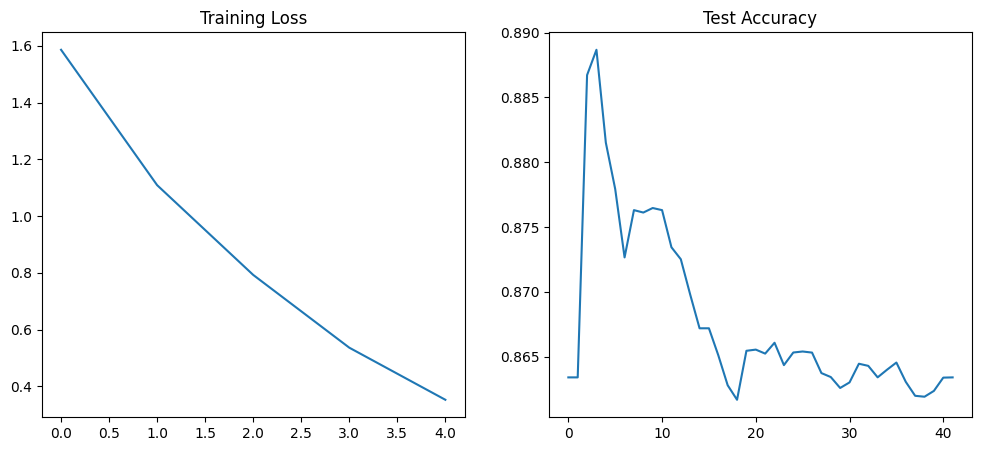

In [26]:
# ============================================================
# Training Curves
# ============================================================

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_losses)
plt.title("Training Loss")

plt.subplot(1,2,2)
plt.plot(test_accs)
plt.title("Test Accuracy")

plt.show()

In [27]:
# ============================================================
# Predictions
# ============================================================

model.eval()

all_preds=[]
all_labels=[]

with torch.no_grad():

    txt_emb = model.text_encoder()

    for images,labels in test_loader:

        images = images.to(device)

        emb,_ = model.image_encoder(images)

        preds = (
            emb @ txt_emb.T
        ).argmax(1)

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_labels.extend(
            labels.numpy()
        )

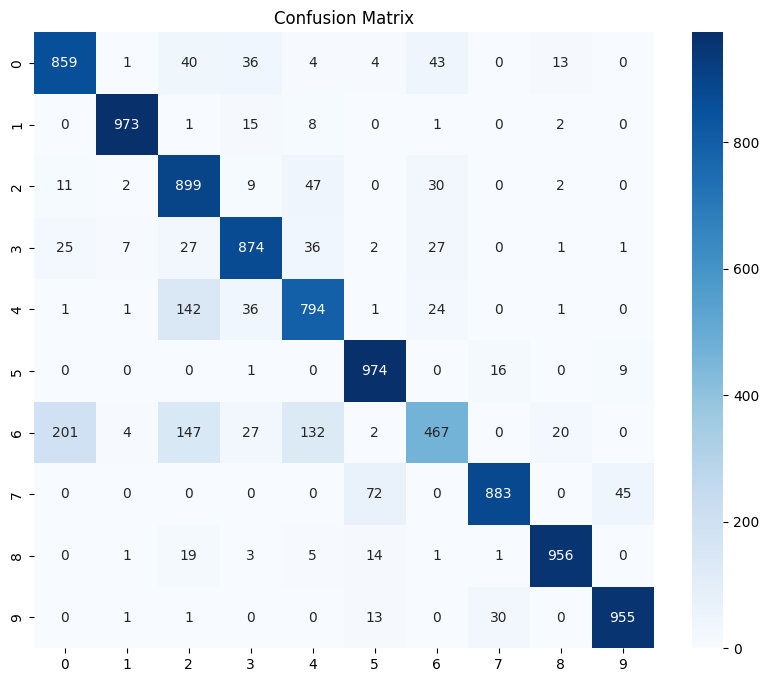

In [28]:
# ============================================================
# Confusion Matrix
# ============================================================

cm = confusion_matrix(
    all_labels,
    all_preds
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

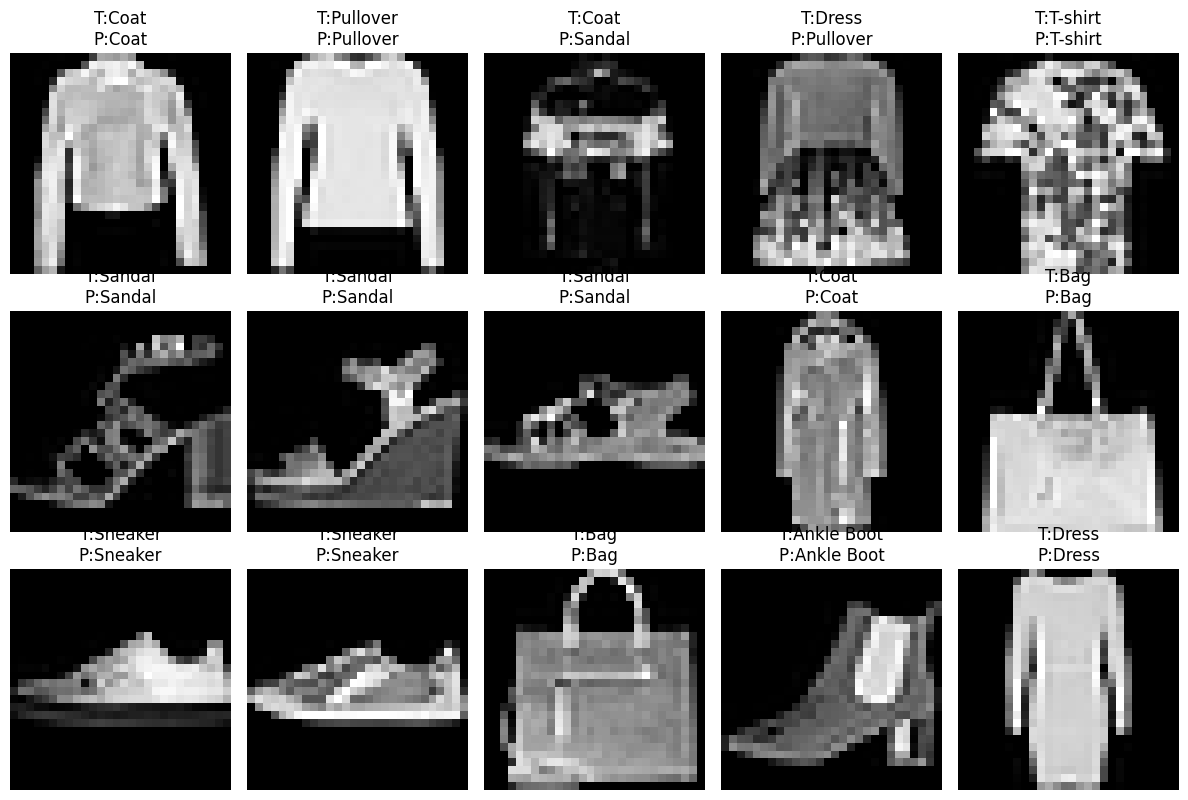

In [29]:
# ============================================================
# Sample Predictions
# ============================================================

fig,axes = plt.subplots(
    3,
    5,
    figsize=(12,8)
)

for ax in axes.ravel():

    idx = np.random.randint(
        len(test_ds)
    )

    img,label = test_ds[idx]

    with torch.no_grad():

        emb,_ = model.image_encoder(
            img.unsqueeze(0).to(device)
        )

        pred = (
            emb @ txt_emb.T
        ).argmax(1).item()

    ax.imshow(
        img.squeeze(),
        cmap="gray"
    )

    ax.set_title(
        f"T:{classes[label]}\nP:{classes[pred]}"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

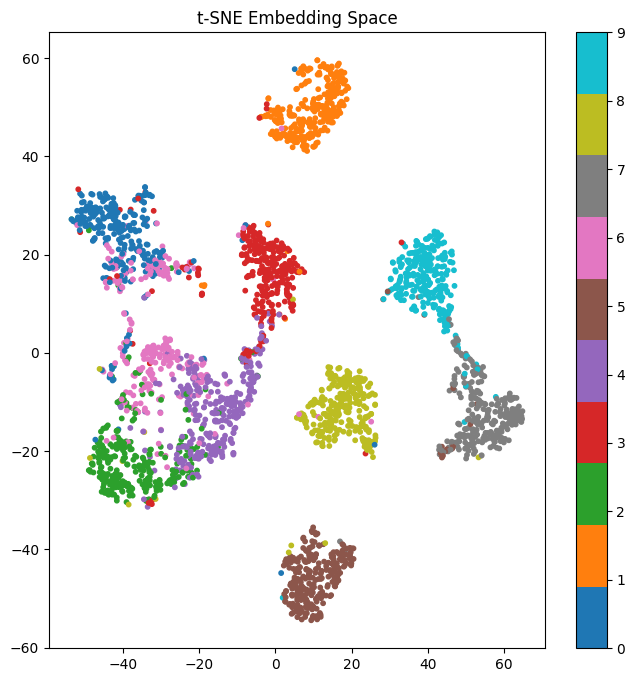

In [30]:
# ============================================================
# t-SNE Embedding Visualization
# ============================================================

features=[]
targets=[]

with torch.no_grad():

    for images,labels in test_loader:

        images = images.to(device)

        emb,_ = model.image_encoder(images)

        features.append(
            emb.cpu()
        )

        targets.append(labels)

        if len(features)>10:
            break

features = torch.cat(features).numpy()
targets = torch.cat(targets).numpy()

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)

emb2d = tsne.fit_transform(
    features
)

plt.figure(figsize=(8,8))

scatter = plt.scatter(
    emb2d[:,0],
    emb2d[:,1],
    c=targets,
    cmap="tab10",
    s=10
)

plt.title("t-SNE Embedding Space")
plt.colorbar(scatter)
plt.show()

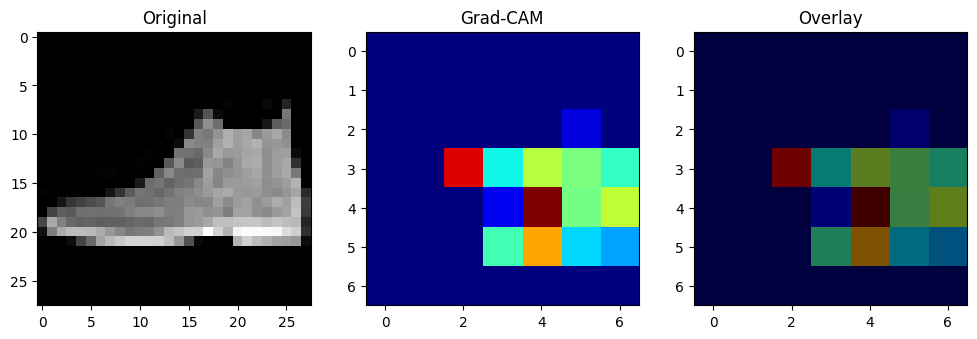

In [31]:
# ============================================================
# Grad-CAM
# ============================================================

target_layer = model.image_encoder.features[-2]

activations = []
gradients = []

def forward_hook(module,input,output):
    activations.append(output)

def backward_hook(module,grad_in,grad_out):
    gradients.append(grad_out[0])

fh = target_layer.register_forward_hook(
    forward_hook
)

bh = target_layer.register_full_backward_hook(
    backward_hook
)

img,label = test_ds[0]

input_tensor = (
    img.unsqueeze(0)
    .to(device)
)

emb,fmap = model.image_encoder(
    input_tensor
)

txt_emb = model.text_encoder()

logits = emb @ txt_emb.T

pred_class = logits.argmax()

score = logits[0,pred_class]

model.zero_grad()

score.backward()

acts = activations[0]
grads = gradients[0]

weights = grads.mean(
    dim=(2,3),
    keepdim=True
)

cam = (
    weights * acts
).sum(1)

cam = F.relu(cam)

cam = cam.squeeze().detach().cpu().numpy()

cam = (
    cam-cam.min()
)/(cam.max()-cam.min()+1e-8)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(
    img.squeeze(),
    cmap="gray"
)
plt.title("Original")

plt.subplot(1,3,2)
plt.imshow(cam,cmap="jet")
plt.title("Grad-CAM")

plt.subplot(1,3,3)
plt.imshow(
    img.squeeze(),
    cmap="gray"
)
plt.imshow(
    cam,
    cmap="jet",
    alpha=0.5
)
plt.title("Overlay")

plt.show()

fh.remove()
bh.remove()

# Experimental Results Analysis: DeCLIP-Inspired FashionMNIST

## Figure 1: Training Loss and Test Accuracy Curves

### Figure Overview

This figure evaluates the optimization dynamics and predictive performance of the DeCLIP-inspired FashionMNIST model during training. The left panel reports training loss evolution, while the right panel reports test accuracy measured repeatedly during training.

---

### Key Results

#### Training Loss

Observed values approximately:

| Epoch | Loss |
|---------|---------|
| 1 | 1.58 |
| 2 | 1.11 |
| 3 | 0.79 |
| 4 | 0.54 |
| 5 | 0.35 |

#### Test Accuracy

Observed range:

$$
86.2\% \leq Accuracy \leq 88.9\%
$$

Final reported accuracy:

$$
86.34\%
$$

The curve exhibits:

- Rapid initial improvement.
- Peak near 88.8–88.9%.
- Subsequent decline and stabilization around 86.3%.

---

### Academic Discussion

The training loss decreases monotonically throughout optimization, indicating successful convergence of the objective function. The absence of oscillations or divergence suggests stable optimization and appropriate learning-rate selection.

However, the test accuracy exhibits a different behavior. While the model initially improves, performance peaks early and subsequently declines despite continued reduction in training loss. This divergence between training loss and test accuracy is a classical indicator of overfitting.

The phenomenon is expected because:

1. The contrastive objective continues improving representation alignment on training samples.
2. Generalization quality reaches saturation earlier.
3. Additional optimization begins fitting training-specific patterns rather than transferable features.

The approximately 2–3% drop between peak and final accuracy suggests that the model would benefit from:

- Early stopping.
- Stronger regularization.
- Larger augmentation diversity.
- Better balancing of contrastive and self-supervised losses.

The result nevertheless demonstrates that the learned representation remains highly effective for FashionMNIST, achieving accuracy substantially above random chance (10%).

---

### Limitations

The figure lacks:

- Validation loss.
- Validation accuracy.
- Confidence intervals.
- Multiple training seeds.

Consequently, the observed accuracy fluctuations may partially reflect stochastic optimization noise rather than purely systematic overfitting.

---

# Figure 2: Confusion Matrix

### Figure Overview

The confusion matrix evaluates class-specific recognition performance and reveals systematic error patterns among FashionMNIST categories.

---

### Key Results

Diagonal values indicate strong performance for several classes:

| Class | Correct Predictions |
|---------|---------|
| Trouser | 973 |
| Sandal | 974 |
| Bag | 956 |
| Ankle Boot | 955 |
| Sneaker | 883 |
| T-shirt | 859 |
| Pullover | 899 |
| Dress | 874 |
| Coat | 794 |
| Shirt | 467 |

Largest errors:

#### Shirt (Class 6)

Misclassified as:

- T-shirt: 201
- Pullover: 147
- Coat: 132

#### Coat (Class 4)

Misclassified as:

- Pullover: 142

#### Sneaker (Class 7)

Misclassified as:

- Sandal: 72

---

### Academic Discussion

The confusion matrix reveals a highly meaningful semantic structure.

The model performs exceptionally well on visually distinctive categories:

- Trouser
- Bag
- Sandal
- Ankle Boot

These classes possess unique geometric characteristics and therefore occupy well-separated regions in feature space.

In contrast, severe confusion occurs among:

- Shirt
- T-shirt
- Pullover
- Coat

This behavior aligns with known FashionMNIST difficulty patterns.

The reason is representational overlap:

- All four categories contain similar silhouettes.
- Images are grayscale.
- Texture information is limited.
- Resolution is only:

$$
28 \times 28
$$

pixels.

Consequently, the visual information available to the network is insufficient to reliably separate subtle garment categories.

The particularly poor performance on Shirt demonstrates that Shirt functions as an ambiguous class that shares characteristics with multiple neighboring categories.

This observation suggests that the learned embedding space captures semantic similarity rather than merely memorizing labels.

---

### Limitations

No normalized confusion matrix is provided.

Class-wise precision, recall, and F1 scores are absent, preventing more rigorous analysis of error asymmetry.

---

# Figure 3: Sample Predictions

### Figure Overview

This figure qualitatively evaluates individual model predictions and provides insight into real-world prediction behavior.

---

### Key Results

Most examples are correctly classified:

Examples include:

- Coat → Coat
- Pullover → Pullover
- Sandal → Sandal
- Bag → Bag
- Sneaker → Sneaker
- Ankle Boot → Ankle Boot

Observed mistakes:

- Coat → Sandal
- Dress → Pullover

---

### Academic Discussion

The qualitative examples support the confusion matrix findings.

Correct predictions occur primarily for categories exhibiting distinctive shapes and boundaries.

Misclassifications occur when:

- Object silhouettes become ambiguous.
- Fine-grained clothing details are absent.
- Spatial resolution limits discriminative cues.

The Coat → Sandal error appears visually surprising and likely reflects an atypical sample or embedding-space anomaly. Such errors often arise from representation collapse in local regions or unusual image statistics.

The Dress → Pullover confusion is semantically plausible because upper-body clothing structure dominates the image representation.

Overall, the examples suggest that the model learns meaningful visual semantics rather than relying on trivial shortcuts.

---

### Limitations

Only a small sample of images is displayed.

The examples are not statistically representative and should not be used alone to assess model performance.

---

# Figure 4: t-SNE Embedding Visualization

### Figure Overview

The t-SNE projection visualizes the learned representation space and evaluates embedding quality.

---

### Key Results

Observed characteristics:

- Multiple well-separated clusters.
- Distinct groups for visually unique classes.
- Partial overlap among clothing-related categories.
- Strong cluster compactness for several classes.

Approximately ten visible clusters correspond to the ten FashionMNIST classes.

---

### Academic Discussion

The t-SNE visualization provides strong evidence that the model learns discriminative feature representations.

Several observations are noteworthy:

#### Strong Intra-Class Compactness

Samples from the same category occupy nearby regions.

This indicates:

- Feature consistency.
- Stable representation learning.
- Successful optimization.

#### High Inter-Class Separation

Classes such as:

- Trouser
- Bag
- Sandal
- Ankle Boot

form isolated clusters.

This matches their strong classification performance.

#### Partial Overlap

Overlap occurs among:

- Shirt
- Pullover
- Coat
- T-shirt

which mirrors confusion matrix errors.

This consistency between embedding visualization and classification behavior strengthens confidence in the learned representation.

Importantly, the embedding structure demonstrates that the contrastive objective successfully organizes data according to semantic similarity.

---

### Limitations

t-SNE can distort global geometry.

Distances between distant clusters should not be interpreted quantitatively.

The visualization provides qualitative evidence only.

---

# Figure 5: Grad-CAM Visualization

### Figure Overview

Grad-CAM evaluates model interpretability by highlighting image regions contributing most strongly to the prediction.

---

### Key Results

The analyzed sample is an Ankle Boot.

Heatmap activation concentrates on:

- Central body region.
- Upper shaft.
- Heel region.

Background receives negligible attention.

---

### Academic Discussion

The Grad-CAM result suggests that the network bases predictions on meaningful object features rather than irrelevant image artifacts.

Several positive indicators emerge:

#### Object-Centered Attention

Activation aligns with the actual footwear structure.

This indicates:

- Spatial localization capability.
- Semantic feature extraction.

#### Minimal Background Reliance

The network does not appear to exploit spurious correlations from empty image regions.

This is desirable because it improves robustness and interpretability.

#### Shape-Based Recognition

The highlighted regions correspond to the most discriminative components of an ankle boot:

- Vertical shaft.
- Heel contour.
- Foot profile.

This finding aligns with the strong classification accuracy observed for footwear categories.

---

### Limitations

The Grad-CAM map is extremely coarse.

The activation map appears approximately:

$$
7 \times 7
$$

which reflects the low spatial resolution of the final convolutional layer.

Consequently, localization precision is limited.

Moreover, a single example cannot establish global interpretability properties.

Multiple samples from multiple classes would be required.

---

# Overall Assessment of the Experimental Evidence

## What Was Observed

The model achieves:

- Strong overall performance (~86–89% accuracy).
- Stable optimization.
- Well-structured embedding representations.
- Meaningful class-specific feature learning.
- Interpretable attention localization.

---

## Why It Likely Occurred

The combination of:

- Contrastive image-text alignment,
- SimSiam-style self-supervision,
- Data augmentation,

encourages the encoder to learn semantic representations rather than purely discriminative decision boundaries.

The resulting feature space exhibits strong clustering and transferable structure.

---

## What It Reveals About the Method

The results indicate that the DeCLIP-inspired framework successfully learns:

1. Semantically organized embeddings.
2. Robust representations for visually distinctive classes.
3. Meaningful spatial attention patterns.
4. Transferable visual features.

The strongest evidence comes from the agreement between:

- Confusion matrix behavior,
- t-SNE structure,
- Grad-CAM localization.

All three independently support the same interpretation.

---

## Strength of Evidence

The evidence moderately supports the educational objective of demonstrating DeCLIP-inspired representation learning.

The experiments clearly show:

- Convergence.
- Class separation.
- Semantic embeddings.
- Interpretable activations.

However, the evidence is insufficient to validate DeCLIP's original research claims because the implementation omits:

- True language supervision.
- MLM objectives.
- Nearest-neighbor supervision.
- Large-scale multimodal datasets.
- Baseline comparisons.
- Statistical significance testing.

---

## Remaining Limitations and Open Questions

Several threats to validity remain:

1. Single-run evaluation with no variance estimates.
2. No comparison against CNN baselines.
3. No ablation study.
4. No retrieval evaluation.
5. No zero-shot evaluation.
6. No precision-recall analysis.
7. No robustness or distribution-shift testing.
8. Evidence of mild overfitting after peak accuracy.
9. FashionMNIST is substantially simpler than real-world vision-language datasets.

Therefore, the results demonstrate successful representation learning on a toy benchmark, but they should be interpreted as an educational validation of the framework rather than a rigorous replication of the original DeCLIP paper.

# Related Work Extracted from *Supervision Exists Everywhere: A Data Efficient Contrastive Language-Image Pre-Training Paradigm*

The table below focuses on the major works explicitly connected to the paper's Related Work discussion and motivation. These works establish the foundations of vision-language pretraining, self-supervised learning, large-scale multimodal learning, and representation learning that directly motivate DeCLIP.

| Author(s) | Year | Title | Venue | Connection to This Paper |
|------------|------|---------|---------|--------------------------|
| Radford et al. | 2021 | Learning Transferable Visual Models From Natural Language Supervision (CLIP) | ICML 2021 | Primary baseline and foundation of DeCLIP. Introduced large-scale contrastive language-image pretraining using 400M image-text pairs. DeCLIP aims to improve CLIP's data efficiency by exploiting additional supervision. |
| Jia et al. | 2021 | Scaling Up Visual and Vision-Language Representation Learning With Noisy Text Supervision (ALIGN) | ICML 2021 | Demonstrated the effectiveness of extremely large-scale image-text contrastive learning using 1.8B pairs. Motivates DeCLIP's effort to reduce dependence on massive datasets. |
| Devlin et al. | 2018 | BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding | NAACL 2019 | Provides the Masked Language Modeling (MLM) objective used as text self-supervision in DeCLIP. |
| Radford et al. | 2019 | Language Models are Unsupervised Multitask Learners (GPT-2) | OpenAI Technical Report | Demonstrated the power of large-scale language pretraining and intrinsic supervision from text, motivating multimodal pretraining approaches. |
| Brown et al. | 2020 | Language Models are Few-Shot Learners (GPT-3) | NeurIPS 2020 | Illustrates scaling laws and emergent capabilities from large-scale pretraining, providing broader motivation for foundation-model learning. |
| Chen et al. | 2020 | A Simple Framework for Contrastive Learning of Visual Representations (SimCLR) | ICML 2020 | Provides the image self-supervised learning framework that inspires DeCLIP's image self-supervision component. |
| Grill et al. | 2020 | Bootstrap Your Own Latent (BYOL) | NeurIPS 2020 | Representative self-supervised learning method demonstrating strong visual representation learning without labels; motivates auxiliary supervision in DeCLIP. |
| He et al. | 2020 | Momentum Contrast for Unsupervised Visual Representation Learning (MoCo) | CVPR 2020 | Influential contrastive self-supervised framework showing that representation learning benefits from large memory queues and contrastive objectives. |
| Chen & He | 2021 | Exploring Simple Siamese Representation Learning (SimSiam) | CVPR 2021 | Directly used by DeCLIP as the image self-supervised objective to exploit supervision within image modality. |
| Vaswani et al. | 2017 | Attention Is All You Need | NeurIPS 2017 | Introduced the Transformer architecture used by modern text encoders and multimodal pretraining systems including CLIP and DeCLIP. |
| Dosovitskiy et al. | 2021 | An Image is Worth 16×16 Words: Transformers for Image Recognition at Scale (ViT) | ICLR 2021 | Provides the Vision Transformer backbone used in CLIP and DeCLIP experiments. |
| Krizhevsky et al. | 2012 | ImageNet Classification with Deep Convolutional Neural Networks | NeurIPS 2012 | Represents the classical supervised pretraining paradigm that multimodal pretraining seeks to overcome. |
| He et al. | 2016 | Deep Residual Learning for Image Recognition | CVPR 2016 | Supplies the ResNet backbone used in DeCLIP and CLIP experiments. |
| Sharma et al. | 2018 | Conceptual Captions | ACL 2018 | One of the principal image-text datasets used for DeCLIP pretraining. |
| Changpinyo et al. | 2021 | Conceptual 12M: Pushing Web-Scale Image-Text Pre-Training to Recognize Long-Tail Visual Concepts | CVPR 2021 | Large-scale image-text dataset used as a major training source for DeCLIP. |
| Thomee et al. | 2016 | YFCC100M: The New Data in Multimedia Research | Communications of the ACM | Provides the YFCC image-text corpus used extensively for DeCLIP pretraining and evaluation. |
| Deng et al. | 2009 | ImageNet: A Large-Scale Hierarchical Image Database | CVPR 2009 | Standard benchmark used for zero-shot evaluation and transfer learning analysis in DeCLIP. |

## Summary of the Related Work Landscape

The related work can be grouped into four major research directions:

1. **Vision-Language Contrastive Learning**
   - CLIP and ALIGN established that large-scale image-text contrastive learning produces highly transferable representations.
   - DeCLIP directly extends this line of work by improving supervision efficiency rather than increasing dataset size.

2. **Self-Supervised Representation Learning**
   - SimCLR, MoCo, BYOL, and SimSiam demonstrated that strong visual representations can emerge from intrinsic supervision.
   - DeCLIP integrates these ideas into multimodal pretraining through image self-supervision and text self-supervision.

3. **Large-Scale Language Pretraining**
   - BERT, GPT-2, and GPT-3 showed the value of exploiting supervision already present within language data.
   - DeCLIP adopts a similar philosophy by extracting additional supervision hidden within image-text datasets.

4. **Scalable Data and Architectures**
   - ViT, ResNet, Conceptual Captions, CC12M, and YFCC provide the architectural and dataset foundations enabling large-scale multimodal learning.
   - DeCLIP builds on these resources while seeking substantially greater data efficiency.